In [6]:
#import all packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
import warnings
import plotly.express as px
import os

warnings.filterwarnings("ignore", category=FutureWarning)

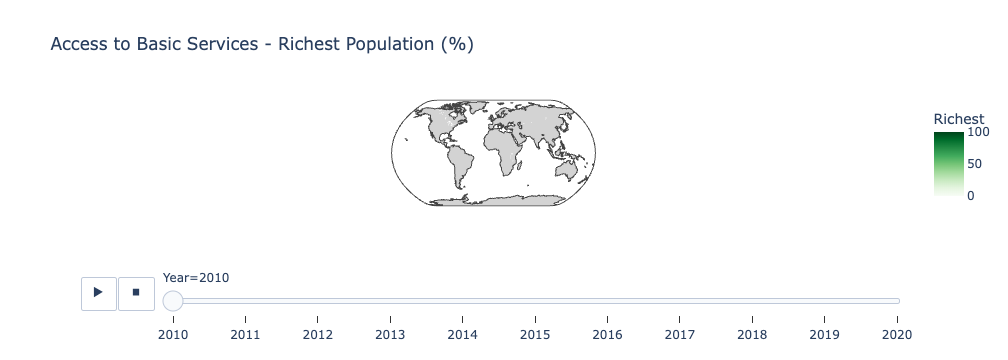

In [9]:
df = pd.read_csv('data/drinking_water_ineq.csv')

for col in ['Poorest', 'Richest']:
    df[col] = df[col].astype(str).str.replace('>', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df= df.dropna(subset=['Year']) # remove the rows where year is empty

df = df.sort_values('Year')

df = df[df['Year'] != 2006]

df['Year'] = df['Year'].astype(int).astype(str)

country_name_mapping = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Congo': 'Congo - Brazzaville',
    'Democratic Republic of the Congo': 'Congo - Kinshasa',
    "Côte d'Ivoire": "Cote d'Ivoire",
    'occupied Palestinian territory*': 'Palestine',
    'Lao People’s Democratic Republic': 'Laos',
    'United Republic of Tanzania': 'Tanzania',
    'Viet Nam': 'Vietnam',
    'Eswatini': 'Swaziland',
    'North Macedonia': 'Macedonia'
}

df['Country'] = df['Country'].replace(country_name_mapping)

metric_to_visualize = 'Richest'  

fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color=metric_to_visualize,
    animation_frame='Year',
    color_continuous_scale=px.colors.sequential.Greens,
    range_color=(0, 100),  
    title=f'Access to Basic Services - {metric_to_visualize} Population (%)',
    hover_name='Country',
    hover_data={
        'Year': True,
        'Poorest': True,
        'Richest': True,
        'Country': False
    }
)

fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)


os.makedirs("visualizations", exist_ok=True)
fig.write_html(f"visualizations/{metric_to_visualize.lower()}_access_map.html")
fig.show()